In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# 1. Check shape
print(f"\n Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")


 Dataset Shape: 1000 rows × 9 columns


In [ ]:
print("\n Column Info:")
print(df.info())


 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [ ]:
print("\n Null Values Check:")
print(df.isnull().sum())


 Null Values Check:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"\n Date Range: {df['Date'].min()} to {df['Date'].max()}")


 Date Range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00


In [ ]:
print("\n" + "=" * 70)
print(" DESCRIPTIVE STATISTICS")
print("=" * 70)

# CORRECT descriptive statistics
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("\n Summary Statistics:")
print(df[numerical_cols].describe())

# CORRECT mean, median, mode, std
print("\n Statistical Measures:")
print("\nMEAN:")
print(df[numerical_cols].mean().round(2))

print("\nMEDIAN:")
print(df[numerical_cols].median().round(2))

print("\nMODE:")
print(df[numerical_cols].mode().iloc[0])

print("\nSTANDARD DEVIATION:")
print(df[numerical_cols].std().round(2))


 DESCRIPTIVE STATISTICS

 Summary Statistics:
              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000

 Statistical Measures:

MEAN:
Age                41.39
Quantity            2.51
Price per Unit    179.89
Total Amount      456.00
dtype: float64

MEDIAN:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

MODE:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

STANDARD DEVIA


 TIME SERIES ANALYSIS


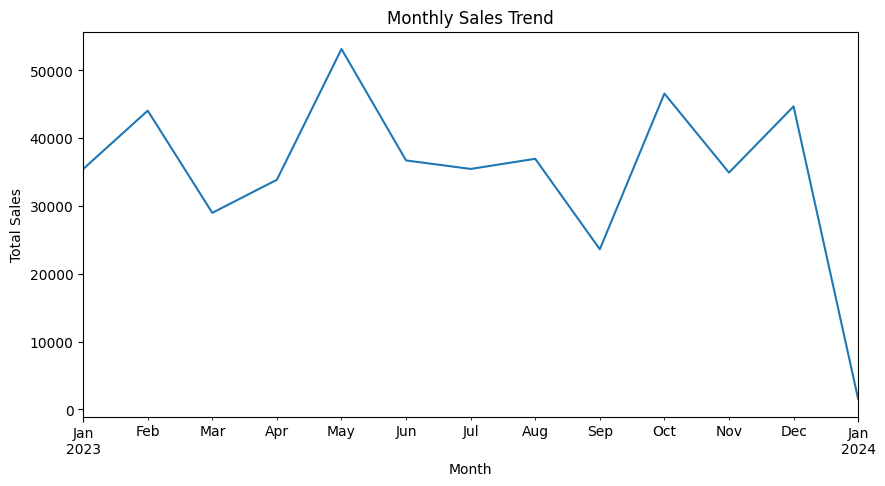

In [ ]:
print("\n" + "=" * 70)
print(" TIME SERIES ANALYSIS")
print("=" * 70)

# Create time-based features
df['Month'] = df['Date'].dt.to_period('M')

# Monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

### Observations: Monthly Sales Trend
- **May 2023** shows the highest sales peak
- **January 2024** has partial data (only 2 transactions)
- Sales show seasonal patterns with multiple peaks
- No month has zero sales

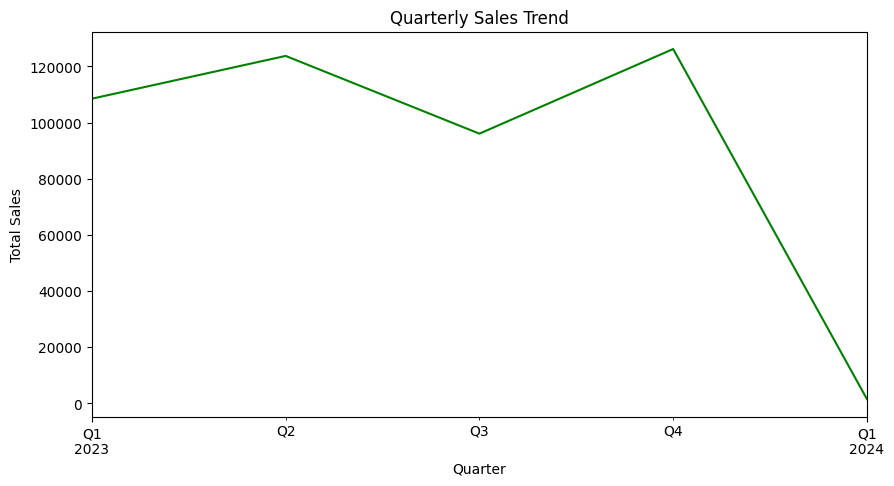

In [ ]:
# Create time-based features
df['Quarter'] = df['Date'].dt.to_period('Q')

# Quarterly
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales.plot(figsize=(10,5), color='green')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

### Observations: Quarterly Sales Trend
- **Q4 2023** shows highest sales
- **Q2 2023** is second highest
- Sales show steady growth from Q1 to Q4
- **Q1 2024** is incomplete (only January 1 data)
- Overall upward trend throughout 2023


 CUSTOMER DEMOGRAPHICS ANALYSIS
Gender
Female    510
Male      490
Name: count, dtype: int64
Age_Group
0-17       0
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
65+        0
Name: count, dtype: int64


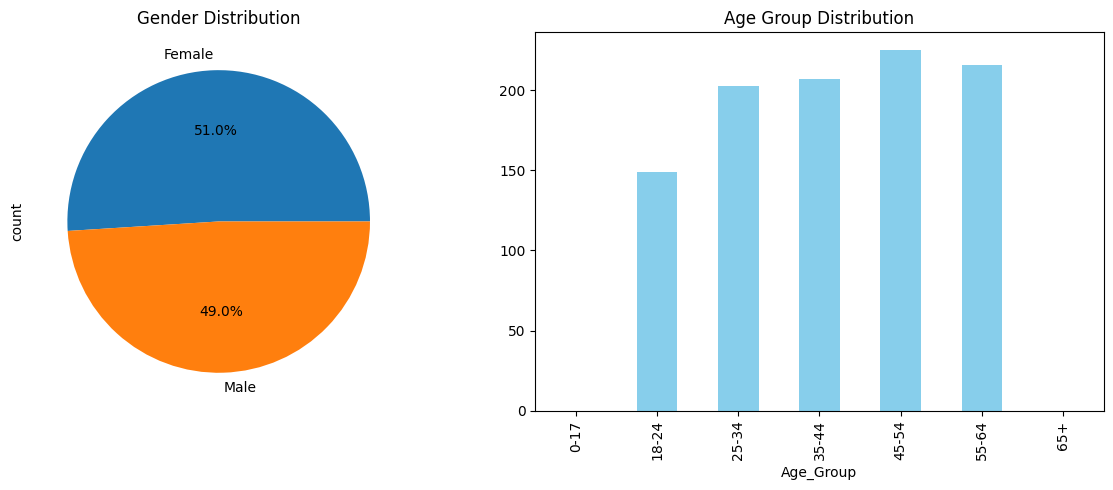

In [ ]:
print("\n" + "=" * 70)
print(" CUSTOMER DEMOGRAPHICS ANALYSIS")
print("=" * 70)

# Age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Gender & Age distribution
print(df['Gender'].value_counts())
print(df['Age_Group'].value_counts().sort_index())

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
df['Gender'].value_counts().plot(kind='pie', ax=ax1, autopct='%1.1f%%')
ax1.set_title('Gender Distribution')
df['Age_Group'].value_counts().sort_index().plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Age Group Distribution')
plt.tight_layout()
plt.show()

### Observations: Gender Distribution
- Customer base is almost evenly split: **Female (51%)** and **Male (49%)**
- Only 20 more female customers than male (510 vs 490)
- Gender does not appear to be a dominant factor in customer behavior

### Observations: Age Group Distribution
- Largest age group: **45-54** (225 customers, 22.5%)
- Second largest: **55-64** (216 customers, 21.6%)
- Third largest: **35-44** (207 customers, 20.7%)
- Age group **25-34** has 203 customers (20.3%)
- Youngest group **18-24** has 149 customers (14.9%)
- No customers under 18 or over 64
- Customer base is fairly evenly distributed across age groups


 PRODUCT ANALYSIS


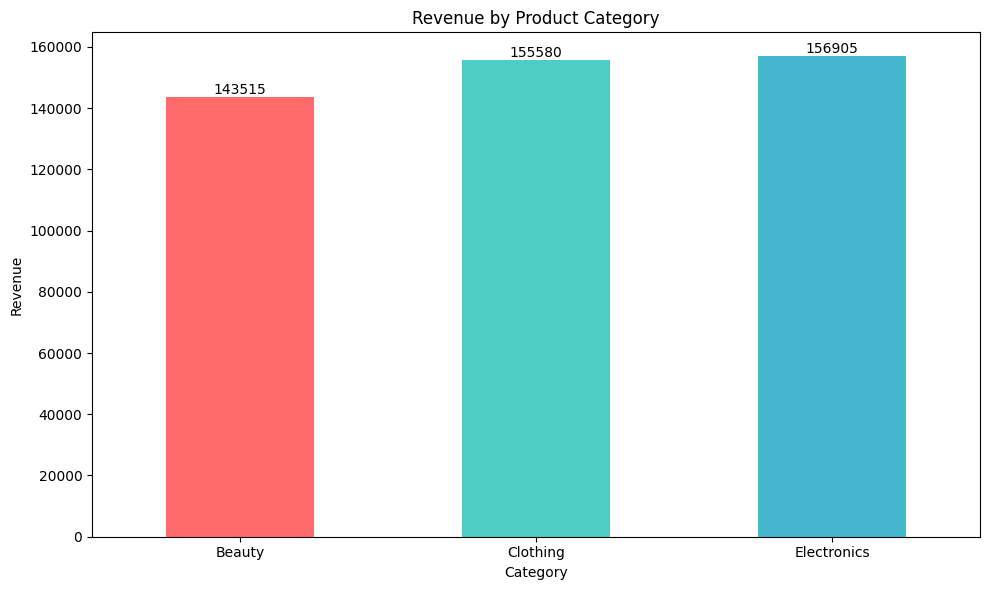

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


In [ ]:
print("\n" + "=" * 70)
print(" PRODUCT ANALYSIS")
print("=" * 70)

# Revenue by category (bar chart)
category_revenue = df.groupby('Product Category')['Total Amount'].sum()

# Plot
ax= category_revenue.plot(kind='bar', figsize=(10, 6), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.bar_label(ax.containers[0])

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(category_revenue)

### Observations: Revenue by Product Category
- **Electronics** generates the highest revenue
- **Clothing** follows closely
- **Beauty** contributes
- Revenue is relatively balanced across all three categories
- Electronics has highest revenue despite likely lower volume
- All three categories are important revenue drivers


 CORRELATION ANALYSIS


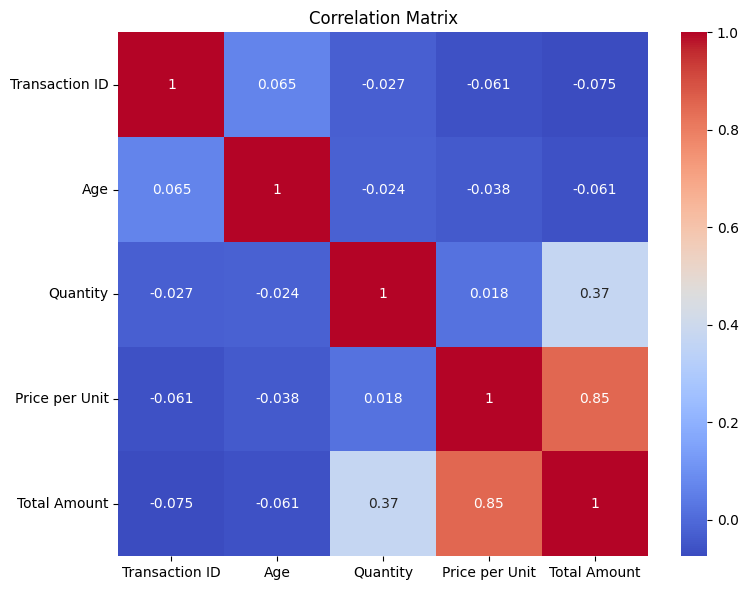

In [ ]:
print("\n" + "=" * 70)
print(" CORRELATION ANALYSIS")
print("=" * 70)


# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


### Observations: Correlation Analysis
- **Strong positive correlation (0.85)** between Total Amount and Price per Unit
  - Higher priced items lead to higher total sales
- **Moderate positive correlation (0.37)** between Total Amount and Quantity
  - Selling more items increases revenue
- **Almost no correlation** between Age and any variable
  - Customer age does not significantly affect spending
- **No correlation** between Transaction ID and any variable (as expected)
- Quantity and Price per Unit have **almost no correlation (0.018)**
  - Customers buy similar quantities regardless of price


 Additional Visualization: Boxplot - Spending Patterns by Age Group


<Figure size 1200x600 with 0 Axes>

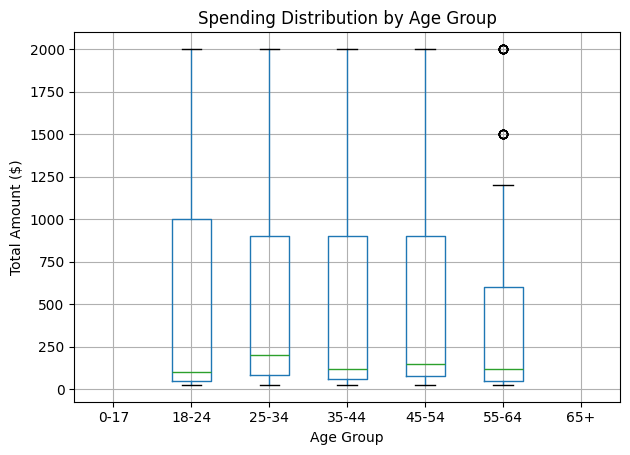

In [ ]:
print("\n" + "=" * 70)
print(" Additional Visualization: Boxplot - Spending Patterns by Age Group")
print("=" * 70)

# Boxplot: Spending distribution across age groups
plt.figure(figsize=(12, 6))
df.boxplot(column='Total Amount', by='Age_Group')
plt.title('Spending Distribution by Age Group')
plt.suptitle('')
plt.xlabel('Age Group')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observations: Boxplot - Spending by Age Group

- **55-64** age group shows highest median spending
- **45-54** age group has widest spending range (most variability)
- **18-24** age group shows lowest spending (consistent with expectations)
- All age groups have **outliers** spending above $1,500
- Older customers (45+) spend more than younger customers
- 65+ and 0-17 groups show **no data** (not present in dataset)

### Non-obvious Insight
- **Older customers (55-64) spend the most**, but they also show the most variation in spending
- **Younger customers (18-24) spend consistently less** - opportunity to increase engagement
- The **45-54 group shows widest spread** - some spend very little, others spend a lot

## Conclusion & Business Recommendations

### Key Findings Summary
1. **May 2023** shows highest monthly sales, followed by September and December
2. **Q4 2023** has highest quarterly performance (holiday season)
3. **Electronics** leads in revenue (156,905), closely followed by Clothing (155,580) and Beauty (143,515)
4. Customer base: **51% Female, 49% Male**, evenly distributed
5. Largest age groups: **45-54 (225 customers)** and **55-64 (216 customers)**
6. **Strong correlation (0.85)** between price and revenue
7. **Age group 55-64** shows highest spending; **18-24** shows lowest


#### 1. Product Strategy
- **Focus on Electronics**: Highest revenue category - introduce premium variants
- **Bundle deals**: Electronics + accessories to increase average order value
- **Beauty for seniors**: Age group 55-64 spends most on Beauty - create targeted products/campaigns
- **Clothing for young**: 18-24 group prefers Clothing - student discounts and social media campaigns

#### 2. Customer Retention
- **Loyalty program**: Target frequent buyers (45-54 and 55-64 age groups)
- **Re-engagement**: Email campaigns for customers inactive 60+ days
- **Referral bonuses**: Since gender split is 51/49, gender-neutral campaigns work best
- **Student discount**: Attract 18-24 group (currently lowest spenders)

#### 3. Seasonal Marketing
- **Pre-holiday push**: Increase marketing in October-November (Q4 is highest)
- **May campaigns**: Since May is the peak month, run promotions in April to build momentum
- **Post-holiday sales**: Boost slow months (Feb-March) with discount events
- **Monthly promotions**: Plan campaigns around seasonal patterns

#### 4. Pricing Strategy
- **Premium pricing works**: Strong correlation (0.85) between price and revenue
- **Volume discounts**: Quantity also affects revenue (0.37) - "Buy more, save more"
- **Tiered pricing**: Different price points for different age groups
- **Bundle pricing**: Increase average order value

#### 5. Additional Recommendations
- **Investigate outliers**: Customers spending >1,500 - potential VIP segment
- **Survey customers**: Understand preferences across age groups
- **Monitor Q4 trends**: Use Q4 performance for annual planning
- **Collect more data**: Location, income, purchase frequency for deeper insights